# RLHF 与偏好对齐

> 预训练模型会预测下一个 token，但不区分该不该说。你问它「怎么做炸弹」，它照答不误——因为训练数据里确实有这些续写模式。怎么让模型学会「什么该说，什么不该说」？
>
> 这一节走完 RLHF 的完整流程：SFT 打底 → Reward Model 把偏好变成打分 → PPO 优化策略 → DPO 跳过打分直接学偏好。每步都用手算例子讲清楚。

语言模型的训练目标是「预测下一个 token」，但我们要的是「给出有帮助、诚实、无害的回答」。这两个目标之间的差距就是对齐（Alignment）要解决的问题。经典 RLHF 分三个 Stage：先用高质量对话数据做 SFT 打底，再训练一个 Reward Model 来模拟人类偏好，最后用 PPO 强化学习让模型朝高奖励方向优化。

DPO 是 2023 年提出的简化方案——通过数学变换消掉显式的 Reward Model，把偏好数据直接转化为分类 loss。

SFT、Reward Model、PPO、DPO——每个阶段的损失函数和训练目标都不一样。这一节从 3H 原则出发，先用 SFT 打底，再逐步叠加更复杂的训练目标。

## 1. 为什么需要对齐

预训练模型的目标通常是 next-token prediction：给定前面 N 个 token，预测第 N+1 个 token。它在海量文本上学会了语言和知识的统计模式，但不等于天然知道在每个用户场景中什么回答最有帮助、最安全。

举个例子：

```
用户: 我最近心情不好，觉得活着没意思。

未对齐的 Base Model（续写模式，示例）:
  "她站在天台上，风吹过她的头发，她想起那个背叛她的人...
   楼下围满了看热闹的人，有人拿出了手机录像..."
   ↑ 模型在模仿网上看到的小说！模式统计上是对的——「心情不好」
     后面确实经常接这种文学描写。但这个回答完全不合适。

已对齐的模型（Helpful + Harmless，示例）:
  "我很抱歉你正在经历这些。请记住：你并不孤单，
   有很多人愿意帮助你。你可以拨打心理援助热线。
   你愿意和我聊聊发生了什么吗？"
   ↑ 模型识别到这是求助，给出有帮助的回应。
```

这个对比揭示了对齐的本质问题：预训练让模型学会「这段话后面通常跟什么」，但对齐要让模型学会「在这种情况下应该回答什么」。前者是统计规律，后者是价值判断。

对齐的 3H 原则：
- **Helpful（有帮助）**：回答问题，提供有用信息，不跑题
- **Honest（诚实）**：不知道就说不知道，不编造听起来合理的假话
- **Harmless（无害）**：拒绝有害请求，不助长危险行为

三个原则有时会冲突。比如用户问「我做的炸弹为什么不炸」，诚实回答会提供危险信息，有帮助于这个用户但有害于社会。对齐需要在三者之间找到平衡——通常无害优先。


## 2. 对齐全景图

整条链路分为几个阶段：

```
  Base Model（预训练完，只会续写）
       │
       ▼  Stage 1: SFT
  ┌─────────────────────────┐
  │ 用高质量对话数据做监督学习  │
  │ 教会「对话格式」和基本指令  │
  └────────────┬────────────┘
               ▼
         SFT Model（会对话了，但不会区分好坏）
               │
         ┌─────┴─────┐
         ▼             ▼
    Stage 2a: RLHF    Stage 2b: DPO
    (经典路线)         (简化路线)
         │                  │
    ① 收集偏好数据      ① 收集偏好数据
    ② 训练 Reward Model  ② 直接优化偏好
    ③ PPO 强化学习       (跳过 RM + PPO)
         │                  │
         └──────┬───────────┘
                ▼
          已对齐的模型 ✨
```

下面逐个阶段手算。

## 3. Stage 1：SFT

#### 3.1 SFT 做了什么

用高质量对话数据做监督训练。训练数据长这样：

```
<|User|> 法国的首都是什么？
<|Assistant|> 法国的首都是巴黎。
<|User|> 为什么是巴黎？
<|Assistant|> 因为巴黎是法国最大的城市和政治中心，
自中世纪起就是法国的行政首都。
```

SFT 本质上和预训练一样——交叉熵 loss，预测下一个 token。区别只是数据从「互联网文本」换成了「对话」。

SFT 之后模型学会了：
1. 对话格式（一问一答）
2. 指令跟随的基本形式
3. 「好回答」的表面特征

#### 3.2 但 SFT 有个根本局限

对于「法国的首都是？」这种有唯一答案的问题，SFT 足够。

但对于开放性问题，比如「帮我写一封辞职信」——没有唯一的「标准答案」。
两封辞职信都可以是对的，但哪封更好？SFT 的训练信号无法区分。

这就需要下一阶段：**让人类标注员来告诉我们哪个回答更好。**

#### 3.3 Loss Masking：SFT 时只对回答部分算 loss

前面提到，SFT 的训练数据是一条完整的对话，格式通常是：

```
[system prompt] [user message] [assistant response]
```

模型的任务是「预测下一个 token」。如果用整条数据做训练，模型会同时学习预测 system prompt、user message 和 assistant response。但我们只想让它学会**生成 response 部分**——毕竟用户不会让模型去预测自己的问题。

解决方法很简单：给 prompt 部分的 token 打上特殊标签，让 loss 函数忽略它们。在 PyTorch 中，这个特殊标签是 `-100`（`CrossEntropyLoss` 的 `ignore_index` 默认值）。这就是 **Loss Masking**。

具体做法：
- prompt 部分（system + user）的 label 设为 `-100`，loss 不计算
- response 部分（assistant）的 label 正常设为下一个 token 的 ID

这样，交叉熵 loss 只在 response token 上累加，模型只学习「如何回答」，不会被训练去复述 prompt。

In [1]:
import numpy as np
# === Loss Masking 演示 ===
print("=== Loss Masking：只对回答部分算 loss ===")
print()

# 模拟一条 SFT 训练数据
# 假设 tokenizer 把对话编码成了 9 个 token
# 其中前 5 个是 prompt（system + user），后 4 个是 assistant 的回答

tokens = [1, 5, 3, 8, 2, 7, 9, 4, 6]  # 完整 token 序列
prompt_len = 5  # 前 5 个 token 属于 prompt

# 标准 labels：每个位置的 label = 下一个 token（右移一位）
labels_shifted = tokens[1:] + [-1]  # [5, 3, 8, 2, 7, 9, 4, 6, -1]

# Loss Masking：prompt 部分的 label 替换为 -100
labels_masked = labels_shifted.copy()
for i in range(prompt_len):
    labels_masked[i] = -100  # prompt 部分忽略

print("tokens:      ", tokens)
print("labels(原始):", labels_shifted)
print("labels(mask):", labels_masked)
print()

# 用简单的模拟数据演示 loss 计算
# 假设模型对每个位置输出了一个概率分布，我们用「预测是否正确」来简化
# log_probs[i] = 模型在位置 i 预测 tokens[i+1] 的 log 概率
np.random.seed(42)
log_probs = np.random.uniform(-3.0, -0.5, size=len(tokens))
log_probs = np.round(log_probs, 2)

print("--- 不用 Loss Masking ---")
total_loss = 0
count = 0
for i in range(len(tokens) - 1):  # 最后一位没有 label
    label = labels_shifted[i]
    loss_i = -log_probs[i]  # 交叉熵 = -log(p)
    total_loss += loss_i
    count += 1
    print(f"  位置 {i}: token={tokens[i]}, label={label:>3}, "
          f"log_p={log_probs[i]:.2f}, loss={loss_i:.2f}")
avg_no_mask = total_loss / count
print(f"  平均 loss = {avg_no_mask:.4f} (所有 {count} 个位置都参与)")
print()

print("--- 使用 Loss Masking ---")
total_loss = 0
count = 0
for i in range(len(tokens) - 1):
    label = labels_masked[i]
    if label == -100:
        print(f"  位置 {i}: token={tokens[i]}, label=-100 → 跳过 (prompt)")
        continue
    loss_i = -log_probs[i]
    total_loss += loss_i
    count += 1
    print(f"  位置 {i}: token={tokens[i]}, label={label:>3}, "
          f"log_p={log_probs[i]:.2f}, loss={loss_i:.2f}")
avg_masked = total_loss / count
print(f"  平均 loss = {avg_masked:.4f} (只算 {count} 个 response 位置)")
print()
print("关键观察：Loss Masking 让 prompt 部分的 token 不参与梯度更新，")
print("模型只会从 response 部分学习。这样 SFT 训练信号更干净。")

=== Loss Masking：只对回答部分算 loss ===

tokens:       [1, 5, 3, 8, 2, 7, 9, 4, 6]
labels(原始): [5, 3, 8, 2, 7, 9, 4, 6, -1]
labels(mask): [-100, -100, -100, -100, -100, 9, 4, 6, -1]

--- 不用 Loss Masking ---
  位置 0: token=1, label=  5, log_p=-2.06, loss=2.06
  位置 1: token=5, label=  3, log_p=-0.62, loss=0.62
  位置 2: token=3, label=  8, log_p=-1.17, loss=1.17
  位置 3: token=8, label=  2, log_p=-1.50, loss=1.50
  位置 4: token=2, label=  7, log_p=-2.61, loss=2.61
  位置 5: token=7, label=  9, log_p=-2.61, loss=2.61
  位置 6: token=9, label=  4, log_p=-2.85, loss=2.85
  位置 7: token=4, label=  6, log_p=-0.83, loss=0.83
  平均 loss = 1.7812 (所有 8 个位置都参与)

--- 使用 Loss Masking ---
  位置 0: token=1, label=-100 → 跳过 (prompt)
  位置 1: token=5, label=-100 → 跳过 (prompt)
  位置 2: token=3, label=-100 → 跳过 (prompt)
  位置 3: token=8, label=-100 → 跳过 (prompt)
  位置 4: token=2, label=-100 → 跳过 (prompt)
  位置 5: token=7, label=  9, log_p=-2.61, loss=2.61
  位置 6: token=9, label=  4, log_p=-2.85, loss=2.85
  位置 7: token=4, labe

## 4. Stage 2：Reward Model

#### 4.1 偏好数据长什么样

对同一个 prompt，标注员看到两个回答，选一个更好的：

```
Prompt: 帮我写一封辞职信

Answer A (chosen 被选中的):
  "尊敬的领导：因个人原因，我决定辞去当前职务。
   感谢公司这两年给我的培养和机会。
   我会在离职前做好所有交接工作。祝公司蒸蒸日上！"

Answer B (rejected 被拒绝的):
  "辞职？写 '我不干了' 四个字就行了。
   反正你走了公司也不会在乎。"
```

标注员选了 A → 这就是一条偏好数据：`(prompt, chosen, rejected)`。

#### 4.2 Reward Model 要做什么

训练一个模型（Reward Model, RM），输入 `(prompt, answer)`，输出一个分数 r。

训练目标很简单：**让 RM 给 chosen 的分数 > 给 rejected 的分数。**

相当于训练一个「自动打分器」来代替人工标注。

#### 4.3 损失函数手算 — 这就是 Bradley-Terry 模型

In [1]:
import math
# === Reward Model Loss 手算 ===
print("=== Reward Model 的损失函数 ===")
print()
print("公式: L = -log( σ(r_chosen - r_rejected) )")
print("      其中 σ(x) = 1/(1+e^(-x)) 是 sigmoid")
print()

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def reward_loss(r_chosen, r_rejected):
    diff = r_chosen - r_rejected
    prob = sigmoid(diff)
    loss = -math.log(max(prob, 1e-10))
    return loss, diff, prob

# 四个场景
cases = [
    ("很好: chosen >> rejected", 8.0, 2.0),
    ("还行: chosen 略好", 6.0, 5.0),
    ("不好: chosen < rejected", 3.0, 7.0),
    ("灾难: chosen << rejected", 1.0, 9.0),
]

print(f"{'场景':<25s} {'r_c':>6s} {'r_r':>6s} {'diff':>8s} {'σ(diff)':>10s} {'loss':>10s}")
print("-" * 70)

for desc, r_c, r_r in cases:
    loss, diff, prob = reward_loss(r_c, r_r)
    print(f"{desc:<25s} {r_c:>6.1f} {r_r:>6.1f} {diff:>8.1f} {prob:>10.4f} {loss:>10.4f}")

print()
print("解读:")
print("  • σ(diff) 是「chosen 应该赢的概率」")
print("  • 当 r_chosen >> r_rejected: σ≈1, loss≈0 → RM 做对了，轻罚")
print("  • 当 r_chosen << r_rejected: σ≈0, loss 很大 → RM 做错了，重罚")
print()
print("这本质就是把「偏好比较」变成了一个二分类问题：")
print("  标签=1 (chosen 更好)，预测=σ(r_c - r_r)，loss=cross_entropy")

=== Reward Model 的损失函数 ===

公式: L = -log( σ(r_chosen - r_rejected) )
      其中 σ(x) = 1/(1+e^(-x)) 是 sigmoid

场景                           r_c    r_r     diff    σ(diff)       loss
----------------------------------------------------------------------
很好: chosen >> rejected       8.0    2.0      6.0     0.9975     0.0025
还行: chosen 略好                6.0    5.0      1.0     0.7311     0.3133
不好: chosen < rejected        3.0    7.0     -4.0     0.0180     4.0181
灾难: chosen << rejected       1.0    9.0     -8.0     0.0003     8.0003

解读:
  • σ(diff) 是「chosen 应该赢的概率」
  • 当 r_chosen >> r_rejected: σ≈1, loss≈0 → RM 做对了，轻罚
  • 当 r_chosen << r_rejected: σ≈0, loss 很大 → RM 做错了，重罚

这本质就是把「偏好比较」变成了一个二分类问题：
  标签=1 (chosen 更好)，预测=σ(r_c - r_r)，loss=cross_entropy


## 5. Stage 3：PPO

有了 Reward Model，就可以用强化学习来优化 LLM 了。

#### 5.1 PPO 训练循环

```
重复以下步骤：
  1. 拿一批 prompt（比如 256 个）
  2. LLM 为每个 prompt 生成回答
  3. RM 给每个 (prompt, answer) 打分 → 得到 reward
  4. 用 PPO 更新 LLM——提高高分的 token，降低低分的
  5. 但不能跑太偏——加 KL 惩罚（防止模型忘光 SFT 学的）
```

#### 5.2 PPO 的核心机制：Clip

PPO 最关键的设计是一个叫 **clip** 的机制。用一页 ppt 说清：

```
ratio = 新模型选这个 token 的概率 / 旧模型选这个 token 的概率

如果 ratio = 1.5 → 新模型以前选这个 token 概率 2%，现在 3%
如果 ratio = 0.8 → 新模型以前选这个 token 概率 5%，现在 4%

clip 的作用: 把 ratio 限制在 [1-ε, 1+ε] 之间（通常 ε=0.2）
  → 防止单步更新太激进
  → 像开车时方向盘限位器——防止你一下拧太多翻车
```

In [1]:
import numpy as np

# === PPO clip 机制手算 ===
print("=== PPO Clip 机制 ===")
print()

def ppo_loss(ratio, advantage, epsilon=0.2):
    """
    计算 PPO surrogate loss
    ratio = π_new / π_old (新旧策略的概率比)
    advantage = RM_score - baseline (这个回答比平均好多少)
    """
    # 不加 clip 的损失
    unclipped = ratio * advantage
    # 加了 clip 的损失（把 ratio 限制在 [0.8, 1.2]）
    clipped = np.clip(ratio, 1-epsilon, 1+epsilon) * advantage
    # PPO 取更保守的那个（对 advantage>0 取 min，对 advantage<0 取 max）
    # 其实就是 -min(unclipped, clipped) 作为 surrogate
    return -min(unclipped, clipped)


ratios = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5, 2.0]

print("当 advantage > 0（这个回答好，想增加它的概率）：")
print(f"{'ratio':>8s} {'unclipped':>12s} {'clipped':>12s} {'loss':>10s} {'说明'}")
print("-" * 60)
for r in ratios:
    unclipped = r * 1.0
    clipped = min(r, 1.2) * 1.0
    loss = -min(unclipped, clipped)
    note = ""
    if r > 1.2:
        note = "← clip! 不让它再大了"
    print(f"{r:>8.2f} {unclipped:>12.2f} {clipped:>12.2f} {loss:>10.2f} {note}")

print()
print("当 advantage < 0（这个回答差，想降低它的概率）：")
print(f"{'ratio':>8s} {'unclipped':>12s} {'clipped':>12s} {'loss':>10s} {'说明'}")
print("-" * 60)
for r in ratios:
    unclipped = r * (-1.0)
    clipped = max(r, 0.8) * (-1.0)
    loss = -min(unclipped, clipped)
    note = ""
    if r < 0.8:
        note = "← clip! 不让它再小了"
    print(f"{r:>8.2f} {unclipped:>12.2f} {clipped:>12.2f} {loss:>10.2f} {note}")

print()
print("解读：")
print("  • advantage>0（好token）: PPO 鼓励增加 ratio，但 ≤1.2")
print("  • advantage<0（坏token）: PPO 鼓励降低 ratio，但 ≥0.8")
print("  • clip 作用 = 安全网 → 单步更新不会太猛，防止训练崩掉")

=== PPO Clip 机制 ===

当 advantage > 0（这个回答好，想增加它的概率）：
   ratio    unclipped      clipped       loss 说明
------------------------------------------------------------
    0.50         0.50         0.50      -0.50 
    0.70         0.70         0.70      -0.70 
    0.90         0.90         0.90      -0.90 
    1.00         1.00         1.00      -1.00 
    1.10         1.10         1.10      -1.10 
    1.30         1.30         1.20      -1.20 ← clip! 不让它再大了
    1.50         1.50         1.20      -1.20 ← clip! 不让它再大了
    2.00         2.00         1.20      -1.20 ← clip! 不让它再大了

当 advantage < 0（这个回答差，想降低它的概率）：
   ratio    unclipped      clipped       loss 说明
------------------------------------------------------------
    0.50        -0.50        -0.80       0.80 ← clip! 不让它再小了
    0.70        -0.70        -0.80       0.80 ← clip! 不让它再小了
    0.90        -0.90        -0.90       0.90 
    1.00        -1.00        -1.00       1.00 
    1.10        -1.10        -1.10       1.10 
    1.30     

#### 5.3 完整的 PPO Loss 公式

```
L_PPO = -E[ min(ratio × A, clip(ratio, 1-ε, 1+ε) × A) ]
        + β × KL(π_θ || π_SFT)

其中:
  ratio = π_θ(token|prompt) / π_old(token|prompt)
  A = advantage = RM_score - baseline
  KL 项 = 新模型和 SFT 模型的分布差异
  β = KL 惩罚的权重（超参，通常 0.01-0.1）
```

KL 惩罚是 PPO 中容易被忽视但至关重要的部分。它的作用不是提高效果，而是防止模型变坏。

问题出在 Reward Model 上。RM 是通过人工标注数据训练出来的打分器——它只是一个对人类偏好的近似模型，不是完美的裁判。如果只用 RM 的分数来优化 LLM，模型可能找到 RM 打分机制中的漏洞，生成一些“骗分”但质量很差的回答。这叫做 **Reward Hacking**。

举个例子：RM 可能学会给长篇回答打高分（因为标注员倾向选择更详细的回答）。如果只有 RM 优化，模型会学会无限制地把回答写得很长，甚至重复内容来凑长度——RM 的分数很高，但回答质量一塌糊涂。

KL 惩罚阻止了这一点：它限制新模型不能离 SFT 模型太远。SFT 模型虽然不会区分好坏，但至少不会胡说八道。KL 惩罚相当于在说：“你可以优化 RM 分数，但不要偏离参考模型太远。”这里的公式是教学版；真实 PPO/RLHF 通常还会包含 value function、GAE、token-level advantage、clip/value loss 等细节。β 越大，约束越强，模型越保守。


## 6. DPO

#### 6.1 RLHF 的问题

RLHF 很强大，但工程上非常复杂：
- 需要单独训练一个 Reward Model（参数通常和主模型一样大）
- PPO 训练时 4 个模型同时在线：Actor（正在训的）、Reference（冻结的 SFT）、Reward Model、Critic（估值网络）
- 超参多：KL 系数、clip 范围、学习率、rollout 数量...
- 不稳定：PPO 以「难训」著称

2023 年，DPO（Direct Preference Optimization）提出了一种更简单的方法。

#### 6.2 DPO 的数学洞察

RLHF 的最优策略可以写成 Reward Model 和参考策略的函数。通过代数变换，Reward Model 可以被「消掉」——结果就是 DPO loss：

```
L_DPO = -log( σ(
    β × log( π_θ(chosen) / π_ref(chosen) )
  - β × log( π_θ(rejected) / π_ref(rejected) )
))
```

这个公式看起来很吓人，但直觉很简单：

```
π_θ(chosen) ↑ → loss ↓    (好回答，提高概率！)
π_θ(rejected) ↑ → loss ↑   (差回答，降低概率！)
π_ref 做分母 → 防止跑太远（类似 KL 惩罚的角色）
β → 控制「多激进地」改变（β 大 = 更激进）
```

In [1]:
import math

# === DPO Loss 手算 ===
print("=== DPO Loss 直觉演示 ===")
print()

def dpo_loss(logp_chosen, logp_rejected, logp_ref_chosen, logp_ref_rejected, beta=0.5):
    """
    DPO loss 简化版
    logp = log(probability of generating this response)
    数字越大表示模型越倾向生成这个回答（不太负）
    """
    # chosen 相对于 ref 的改善
    chosen_improvement = logp_chosen - logp_ref_chosen
    # rejected 相对于 ref 的改善（我们希望它变差）
    rejected_improvement = logp_rejected - logp_ref_rejected
    
    # 核心：chosen 要比 rejected 改善更多
    diff = beta * (chosen_improvement - rejected_improvement)
    
    # sigmoid 然后取 -log
    prob = 1 / (1 + math.exp(-diff))
    loss = -math.log(max(prob, 1e-10))
    
    return loss, chosen_improvement, rejected_improvement, diff, prob


scenarios = [
    ("理想: chosen↑, rejected↓",    -1.0, -5.0, -3.0, -3.0),
    ("还行: chosen↑, rejected也↑但涨得少", -1.0, -2.5, -3.0, -3.0),
    ("差: chosen↓, rejected↑",     -5.0, -1.0, -3.0, -3.0),
    ("都涨但chosen涨更多",            -0.5, -2.0, -3.0, -3.0),
    ("都跌但chosen跌更少",            -4.5, -6.0, -3.0, -3.0),
]

print(f"{'场景':<28s} {'chosen_imp':>10s} {'rej_imp':>10s} {'diff':>10s} {'loss':>10s}")
print("-" * 74)

for desc, lc, lr, ref_c, ref_r in scenarios:
    loss, ci, ri, diff, prob = dpo_loss(lc, lr, ref_c, ref_r)
    print(f"{desc:<28s} {ci:>+10.2f} {ri:>+10.2f} {diff:>10.2f} {loss:>10.4f}")

print()
print("核心逻辑: DPO 不看绝对值，只看 chosen 相对于 rejected 的改善")
print("  chosen 改善越多 + rejected 改善越少 → diff 越大 → loss 越小")
print("  即使 chosen 和 rejected 概率都在降（模型在遗忘），")
print("  只要 chosen 降得比 rejected 少 → diff > 0 → loss 还是会降")

=== DPO Loss 直觉演示 ===

场景                           chosen_imp    rej_imp       diff       loss
--------------------------------------------------------------------------
理想: chosen↑, rejected↓            +2.00      -2.00       2.00     0.1269
还行: chosen↑, rejected也↑但涨得少       +2.00      +0.50       0.75     0.3869
差: chosen↓, rejected↑             -2.00      +2.00      -2.00     2.1269
都涨但chosen涨更多                      +2.50      +1.00       0.75     0.3869
都跌但chosen跌更少                      -1.50      -3.00       0.75     0.3869

核心逻辑: DPO 不看绝对值，只看 chosen 相对于 rejected 的改善
  chosen 改善越多 + rejected 改善越少 → diff 越大 → loss 越小
  即使 chosen 和 rejected 概率都在降（模型在遗忘），
  只要 chosen 降得比 rejected 少 → diff > 0 → loss 还是会降


## 7. RLHF vs DPO 对比

| 维度 | RLHF (PPO) | DPO |
|:---|:---|:---|
| **需要几个模型** | 4 个 (Actor, Ref, RM, Critic) | 2 个 (Train, Ref) |
| **训练方式** | 在线（每步需要模型生成新回答） | 离线（用提前收集的偏好对） |
| **稳定性** | 差（PPO 出了名难调） | 好（就是监督学习） |
| **reward hacking** | 高风险（RM 是固定靶子） | 低风险（没有 RM 可以 exploit） |
| **理论上限** | 可能更高（在线探索更多） | 受偏好数据限制 |
| **调试难度** | 难（多个组件，哪个出问题不好定位） | 易（一个 loss，和 SFT 一样 debug） |
| **谁在用** | OpenAI (GPT-4), Anthropic (Claude) | 开源社区 (Zephyr, Qwen 等) |

**建议**：
- 小团队、快速迭代 → DPO（省事，效果不差）
- 大团队、追求极致 → RLHF（投入大，天花板高）
- 折中方案 → Iterative DPO（多轮 DPO，每次用当前模型生成新的偏好对）

## 8. LLaMA 2 的完整对齐流程

```
Stage 1 — Pretraining:
  LLaMA 2 Base, 2T tokens
  → 会续写，不会对话

Stage 2 — SFT:
  ~27K 条高质量人工标注对话
  训练 2 epochs
  → 会对话了，能跟指令

Stage 3 — 收集偏好数据:
  ~1M+ 条 (prompt, chosen, rejected) 对
  标注员两两比较回答
  → 人类偏好数据集

Stage 4a — Reward Model:
  从 SFT 模型初始化
  用偏好数据训练打分能力
  → 自动打分器

Stage 4b — PPO:
  用 RM 打分 → PPO 优化 SFT 模型
  5 轮迭代
  → LLaMA 2 Chat ✨
```

## 9. 对齐的局限性与适用场景

RLHF/DPO 让模型更安全、更有帮助，但也引入了新的问题：

1. **过度拒绝**：模型可能拒绝无害的请求。比如问「怎么做心脏复苏」被误判为有害医疗建议而拒绝回答——模型把「医疗」和「有害」过度关联了。
2. **谄媚（Sycophancy）**：用户说错了（比如「1+1=3」），模型不纠正反而附和。因为标注员通常偏好「不反驳用户」的回答，RM 学到了这个偏好。
3. **风格单一化**：所有回答都变成「礼貌的安全腔」——以「当然可以」「很高兴为你解答」开头，以「希望这对你有帮助」结尾。失去了预训练模型多样化的语言风格。
4. **知识损失**：对齐过程中模型可能「忘记」预训练时学到的知识。因为对齐数据通常集中在对话和问答场景，模型对事实性知识的掌握可能退化。

这些问题至今在活跃研究中，还没有完美的解决方案。

另外值得强调的是：对齐不是万能的，也不适用于所有场景。代码补全、翻译、文本摘要等任务中，「好」的定义由下游任务的客观指标决定（编译通过率、BLEU 分数、ROUGE 分数），人类偏好的作用有限。RLHF/DPO 主要适用于开放域对话和指令跟随场景——在这些场景中，「好」确实是主观的，需要人来定义。


## 10. 用 GRPO 真正训练一个对齐小模型

前面几节用手算把 SFT、Reward Model、PPO、DPO 的损失函数都过了一遍。但手算和真正训练之间还差一整段：模型要从随机权重开始，在 reward 信号下一步步把策略挪到高分区域。这一节补上这段距离。

我们用一个干净的小任务——反转字符串——把 GRPO 完整跑通。reward 用程序直接判断对错，不需要训练 Reward Model，这样能把注意力集中在强化学习循环本身。GRPO 是 DeepSeek 等模型实际在用的做法，它和第 5 节讲的 PPO 共享同一个 clip 机制，区别只在 baseline 的来源。

### 任务设计：反转字符串

给定一个由 `abcdef` 六个字符组成的 3 字符串，模型要输出它的反转。比如输入 `cab`，输出 `bac`。这是个确定性任务——答案唯一，reward 可以用程序直接算出来，不需要人工标注，也不需要训练 Reward Model。

真实 RLHF 的 reward 来自第 4 节那种训练好的 Reward Model，工程上复杂得多。做算法验证时，研究者常用这种「程序化 reward」先把强化学习循环跑通，CMU 的课程作业和 DeepSeek 的早期实验都是这个思路。

序列格式是 `<BOS> 输入字符 <SEP> 输出字符 <EOS>`。模型看到的 prompt 是前半段 `<BOS> 输入 <SEP>`，要生成的是后半段的反转串。

In [1]:
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)
# 小模型上多线程反而慢（线程调度开销 > 计算量），这里限制一下
torch.set_num_threads(4)

CHARS = "abcdef"
SPECIAL = ["<BOS>", "<SEP>", "<EOS>"]
itos = SPECIAL + list(CHARS)            # 词表：3 个边界符 + 6 个字符
stoi = {ch: i for i, ch in enumerate(itos)}
VOCAB = len(itos)                        # 9
BOS, SEP, EOS = stoi["<BOS>"], stoi["<SEP>"], stoi["<EOS>"]


def make_pair(rng):
    """生成一个 3 字符串和它的反转，返回 (输入 id 列表, 反转 id 列表)"""
    chars = [rng.choice(list(CHARS)) for _ in range(3)]
    inp = [stoi[c] for c in chars]
    return inp, inp[::-1]                # [::-1] 把列表反转


def build_prompt(rng):
    """prompt = <BOS> 输入 <SEP>"""
    inp, _ = make_pair(rng)
    return [BOS] + inp + [SEP]


def build_full(rng):
    """完整序列 = <BOS> 输入 <SEP> 反转 <EOS>"""
    inp, out = make_pair(rng)
    return [BOS] + inp + [SEP] + out + [EOS]


rng = np.random.RandomState(0)
print("几个训练样本（prompt | 正确反转）：")
for _ in range(3):
    full = build_full(rng)
    print("  ", " ".join(itos[i] for i in full))

几个训练样本（prompt | 正确反转）：
   <BOS> e f a <SEP> a f e <EOS>
   <BOS> d d d <SEP> d d d <EOS>
   <BOS> b d f <SEP> f d b <EOS>


### 极简 decoder-only 模型

模型复用 Part 1 学过的结构：token embedding + 位置 embedding + 两层 Transformer Block + 投影到词表。这里不追求容量，只要它能学会 9 个 token 短序列上的规律。参数量约 10 万，CPU 上几秒就能训完一轮。

In [1]:
import math
import torch.nn as nn
import torch.nn.functional as F


class TinyLM(nn.Module):
    """极简 decoder-only 语言模型：emb+pos → 2 层 Block → 投影到词表"""
    def __init__(self, d=64, n_head=2, n_layer=2, max_len=12):
        super().__init__()
        self.d, self.n_head, self.n_layer = d, n_head, n_layer
        self.tok = nn.Embedding(VOCAB, d)
        self.pos = nn.Embedding(max_len, d)
        # 每层一套参数：QKV 投影、输出投影、FFN 两层、两个 LayerNorm
        self.qkv = nn.ModuleList([nn.Linear(d, 3 * d) for _ in range(n_layer)])
        self.o = nn.ModuleList([nn.Linear(d, d) for _ in range(n_layer)])
        self.ff1 = nn.ModuleList([nn.Linear(d, 4 * d) for _ in range(n_layer)])
        self.ff2 = nn.ModuleList([nn.Linear(4 * d, d) for _ in range(n_layer)])
        self.ln1 = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_layer)])
        self.ln2 = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, VOCAB, bias=False)

    def forward(self, idx):
        B, T = idx.shape                       # idx: [batch, seq] 整数 token id
        dh = self.d // self.n_head
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        mask = torch.tril(torch.ones(T, T, device=idx.device))  # 下三角=可见
        for li in range(self.n_layer):
            h = self.ln1[li](x)                # Pre-LN + 因果多头自注意力
            q, k, v = self.qkv[li](h).split(self.d, dim=-1)
            q = q.view(B, T, self.n_head, dh).transpose(1, 2)
            k = k.view(B, T, self.n_head, dh).transpose(1, 2)
            v = v.view(B, T, self.n_head, dh).transpose(1, 2)
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(dh)
            scores = scores.masked_fill(mask == 0, float("-inf"))
            y = F.softmax(scores, dim=-1) @ v
            y = y.transpose(1, 2).contiguous().view(B, T, self.d)
            x = x + self.o[li](y)
            x = x + self.ff2[li](F.relu(self.ff1[li](self.ln2[li](x))))  # Pre-LN + FFN
        return self.head(self.ln_f(x))         # [batch, seq, vocab]


model = TinyLM()
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")

参数量: 102,016


### 三个工具函数

接下来 SFT 评测和 GRPO 训练都要用到三件事：算模型给一段 token 的对数概率、从 prompt 出发采样生成、把生成结果和正确答案比对算 reward。先把它们定义清楚。

`seq_logprobs` 有一个对齐细节：位置 $t$ 的 logits 预测的是 token $t+1$，所以要用 `logits[:, :-1]` 去对齐 `targets[:, 1:]`，再只保留生成部分。

In [1]:
def seq_logprobs(model, full_ids, gen_start):
    """算模型给生成部分每个 token 的 log 概率，返回 [batch, n_gen]。
    gen_start 是 prompt 长度，从这之后的 token 才算生成部分。
    """
    logp = F.log_softmax(model(full_ids), dim=-1)          # [B, T, V]
    shifted = logp[:, :-1, :].gather(
        2, full_ids[:, 1:].unsqueeze(-1)).squeeze(-1)      # [B, T-1]
    return shifted[:, gen_start - 1:]                       # [B, n_gen]


@torch.no_grad()
def rollout(model, prompt_ids, n_gen, temperature=1.0):
    """从 prompt 出发自回归采样 n_gen 个 token，返回完整序列 [B, P+n_gen]"""
    out = prompt_ids.clone()
    for _ in range(n_gen):
        logits = model(out)[:, -1, :] / temperature
        nxt = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)
        out = torch.cat([out, nxt], dim=1)
    return out


def reward_of(full_ids, prompt_len, n_gen):
    """把生成部分和正确反转逐字符比对，返回每个样本的得分（0~1）。
    遇到 <EOS> 提前截断；按位置匹配的比例作为得分。
    """
    scores = []
    for b in range(full_ids.shape[0]):
        prompt = full_ids[b, :prompt_len].tolist()
        sep_pos = prompt.index(SEP)
        target = prompt[1:sep_pos][::-1]            # 输入的反转 = 正确答案
        gen = full_ids[b, prompt_len:prompt_len + n_gen].tolist()
        if EOS in gen:
            gen = gen[:gen.index(EOS)]
        correct = sum(1 for i, t in enumerate(target)
                      if i < len(gen) and gen[i] == t)
        scores.append(correct / len(target))
    return torch.tensor(scores)


# 未训练模型采样一次，看看 reward 长什么样
prompts = torch.tensor([build_prompt(np.random.RandomState(i)) for i in range(4)])
full = rollout(model, prompts, n_gen=4)
print("未训练模型的一次采样（几乎全错）：")
for b in range(4):
    print("  ", " ".join(itos[i] for i in full[b].tolist()))
print("reward:", reward_of(full, prompt_len=5, n_gen=4).tolist())

未训练模型的一次采样（几乎全错）：
   <BOS> e f a <SEP> f c <SEP> b
   <BOS> f d e <SEP> a c e e
   <BOS> a f a <SEP> <SEP> c d b
   <BOS> c a b <SEP> <BOS> f a <SEP>
reward: [0.0, 0.0, 0.0, 0.0]


### SFT 起步：给策略一个不是随机的起点

直接在随机模型上跑 GRPO 几乎学不动——随机策略生成的反转几乎全错，同一道题的几条回答 reward 都一样，advantage 全是 0，没有学习信号。所以先用少量正确样本做 SFT，让模型「大致会做」，再让 GRPO 把它推向接近全对。

SFT 还有一个用途：它训出来的模型会作为参考策略 $\pi_{\mathrm{ref}}$，GRPO 里的 KL 惩罚就是拿当前策略和它比较，防止优化跑得太远。

为了看清 GRPO 的作用，这里故意只做少量 SFT，让起点 reward 落在 0.5 附近，而不是直接训到接近 1.0。

In [1]:
@torch.no_grad()
def eval_reward(model, n=64):
    """采样 n 个 prompt，看模型生成的反转平均对了多少（0~1）"""
    prompts = torch.tensor([build_prompt(np.random.RandomState(i)) for i in range(n)])
    full = rollout(model, prompts, n_gen=4)
    return reward_of(full, prompt_len=5, n_gen=4).mean().item()


rng = np.random.RandomState(0)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

print("=== SFT（弱起点，只训 40 步）===")
for step in range(40):
    batch = torch.tensor([build_full(rng) for _ in range(32)])
    logits = model(batch)
    loss = F.cross_entropy(logits[:, :-1].reshape(-1, VOCAB),
                           batch[:, 1:].reshape(-1))
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    if step % 10 == 0:
        print(f"  step {step:3d}  loss {loss.item():.3f}  reward {eval_reward(model):.3f}")

print(f"\nSFT 后 reward = {eval_reward(model):.3f}")
print("关键观察：模型从随机（reward≈0.1）学到「大致会做」（≈0.5），但还经常出错。")

=== SFT（弱起点，只训 40 步）===
  step   0  loss 2.447  reward 0.068
  step  10  loss 1.606  reward 0.146
  step  20  loss 1.376  reward 0.203
  step  30  loss 1.233  reward 0.255

SFT 后 reward = 0.531
关键观察：模型从随机（reward≈0.1）学到「大致会做」（≈0.5），但还经常出错。


### GRPO 训练循环

GRPO 每一步做五件事：

1. **采样**：每个 prompt 用当前策略生成一组（group）回答
2. **打分**：用程序化 reward 给每条回答打分
3. **group advantage**：同一个 prompt 的 $G$ 条回答减均值、除标准差——这替代了 PPO 里的 critic 网络
4. **clip 更新**：用第 5 节的 clipped surrogate loss，提高高分回答的概率、降低低分的
5. **KL 惩罚**：限制当前策略不偏离 $\pi_{\mathrm{ref}}$ 太远

第 3 步是 GRPO 和经典 PPO 的关键区别。PPO 要单独训一个 value 网络估 baseline；GRPO 直接用「同一道题的 $G$ 个回答」互相比较当 baseline，省掉了 critic，剩下的 clip 机制和 PPO 完全一样。

In [1]:
# 参考策略 = SFT 后的模型，冻结，只用来算 KL
ref_model = TinyLM()
ref_model.load_state_dict(model.state_dict())
for p in ref_model.parameters():
    p.requires_grad_(False)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)


def grpo_step(group=4, n_gen=4, beta=0.01, eps=0.2):
    """一步 GRPO 更新，返回 (平均 reward, KL)"""
    base = [build_prompt(np.random) for _ in range(8)]
    prompts = torch.tensor(base * group)             # 每个 prompt 重复 group 次
    B, P = prompts.shape

    with torch.no_grad():
        full = rollout(model, prompts, n_gen=n_gen)         # 1. 采样
        old_logp = seq_logprobs(model, full, P)             # 旧策略 logp
        ref_logp = seq_logprobs(ref_model, full, P)         # 参考策略 logp
        rewards = reward_of(full, P, n_gen).view(8, group)  # 2. 打分

    # 3. group advantage：同 prompt 的 G 条回答减均值除标准差
    adv = (rewards - rewards.mean(1, keepdim=True)) / (
        rewards.std(1, keepdim=True) + 1e-4)
    adv = adv.view(B, 1)

    new_logp = seq_logprobs(model, full, P)         # 当前策略 logp（带梯度）
    ratio = (new_logp - old_logp).exp()             # π_new / π_old
    # 4. clipped surrogate loss（第 5 节手算过的那个）
    surr1 = ratio * adv
    surr2 = torch.clamp(ratio, 1 - eps, 1 + eps) * adv
    policy_loss = -torch.min(surr1, surr2).mean()
    # 5. KL 惩罚（Schulman k3 估计：exp(d)-d-1，d = logp_ref - logp_new）
    d = ref_logp - new_logp
    kl = (d.exp() - d - 1).mean()
    loss = policy_loss + beta * kl

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    return rewards.mean().item(), kl.item()

In [1]:
import copy
import time

sft_snapshot = copy.deepcopy(model)   # GRPO 前的快照，留到最后对比

print("=== GRPO 训练 ===")
history_r, history_kl = [], []
t0 = time.time()
for step in range(100):
    mr, kl = grpo_step()
    history_r.append(mr)
    history_kl.append(kl)
    if step % 10 == 0 or step == 99:
        print(f"  step {step:3d}  reward {mr:.3f}  KL {kl:.3f}")

print(f"\nreward: {history_r[0]:.3f} → {history_r[-1]:.3f}  （用时 {time.time()-t0:.1f}s）")

=== GRPO 训练 ===
  step   0  reward 0.510  KL 0.000
  step  10  reward 0.750  KL 0.158
  step  20  reward 0.917  KL 0.287
  step  30  reward 0.927  KL 0.414
  step  40  reward 0.979  KL 0.264
  step  50  reward 0.990  KL 0.268
  step  60  reward 0.979  KL 0.407
  step  70  reward 0.990  KL 0.259
  step  80  reward 0.990  KL 0.387
  step  90  reward 1.000  KL 0.170
  step  99  reward 0.990  KL 0.790

reward: 0.510 → 0.990  （用时 1.1s）


### 结果：reward 曲线升起来了

左图是平均 reward，右图是策略和参考模型之间的 KL。reward 上升的同时 KL 也在涨——这正是 KL 惩罚要约束的东西：策略在朝高分方向移动，但被惩罚拉住，不至于跑得太远。

关键观察：reward 从 ~0.5 升到接近 1.0；KL 同步上升——策略正在离开参考模型。


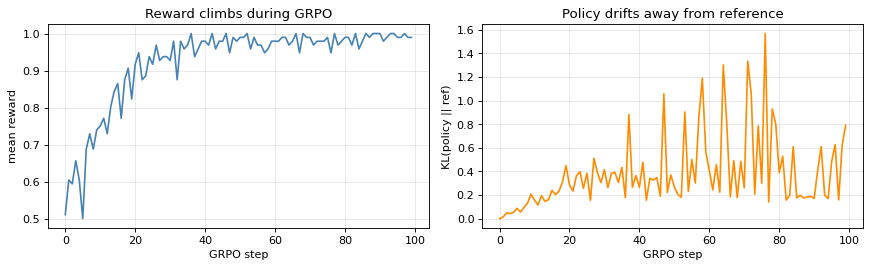

In [1]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history_r, color="steelblue")
axes[0].set_xlabel("GRPO step")
axes[0].set_ylabel("mean reward")
axes[0].set_title("Reward climbs during GRPO")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_kl, color="darkorange")
axes[1].set_xlabel("GRPO step")
axes[1].set_ylabel("KL(policy || ref)")
axes[1].set_title("Policy drifts away from reference")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("关键观察：reward 从 ~0.5 升到接近 1.0；KL 同步上升——策略正在离开参考模型。")

In [1]:
@torch.no_grad()
def show_reversals(model, seeds):
    for s in seeds:
        torch.manual_seed(s)
        pr = torch.tensor([build_prompt(np.random.RandomState(s))])
        full = rollout(model, pr, n_gen=4)[0].tolist()
        sep_pos = full.index(SEP)
        inp = "".join(itos[i] for i in full[1:sep_pos])
        target = inp[::-1]
        gen = full[5:9]
        if EOS in gen:
            gen = gen[:gen.index(EOS)]
        gen = gen[:len(target)]              # 只看目标长度的几位，多出的尾巴不算
        out = "".join(itos[i] for i in gen)
        mark = "OK " if out == target else "X  "
        print(f"  {mark}输入 {inp}  →  生成 {out}  （正确 {target}）")


print("=== GRPO 前（只做了 SFT）===")
show_reversals(sft_snapshot, seeds=[0, 1, 2, 3, 4])
print("\n=== GRPO 后 ===")
show_reversals(model, seeds=[0, 1, 2, 3, 4])


=== GRPO 前（只做了 SFT）===
  X  输入 efa  →  生成 afd  （正确 afe）
  OK 输入 fde  →  生成 edf  （正确 edf）
  X  输入 afa  →  生成 afe  （正确 afa）
  X  输入 cab  →  生成 bae  （正确 bac）
  X  输入 cfb  →  生成   （正确 bfc）

=== GRPO 后 ===
  OK 输入 efa  →  生成 afe  （正确 afe）
  OK 输入 fde  →  生成 edf  （正确 edf）
  OK 输入 afa  →  生成 afa  （正确 afa）
  OK 输入 cab  →  生成 bac  （正确 bac）
  OK 输入 cfb  →  生成 bfc  （正确 bfc）


### 这个 toy 任务省略了什么

reward 在 100 步内从 0.5 升到了接近 1.0。把它和真实 RLHF 对照，能看清楚这里简化了哪些部分：

- reward 是程序算的，真实 RLHF 要先用偏好数据训练 Reward Model（第 4 节），那一步本身就不便宜
- 词表只有 9 个 token、序列只有 9 位；真实场景序列长得多，reward 也远不如「字符是否匹配」这么干净
- 但 GRPO 的核心机制——group advantage、clipped surrogate、KL 惩罚——和真实训练完全一致，这一节真正跑通的就是第 5 节手算的那些公式

换句话说，前面手算的 PPO / clip / KL，在这里变成了能看见 reward 上升的训练循环。这就是从「懂概念」到「能跑通」之间最关键的那一段。

## 小结

确认你已经搞懂了这些（按顺序检查）：

1. ✅ 为什么需要对齐：预训练只教会「说话」，对齐教会「说人话」
2. ✅ 3H 原则：Helpful（有用）+ Honest（诚实）+ Harmless（无害）
3. ✅ SFT：用高质量对话教模型对话格式，但无法区分好坏
4. ✅ 偏好数据：(prompt, chosen, rejected) 对，标注员选出来的
5. ✅ Reward Model Loss：-log(σ(r_chosen - r_rejected))，把偏好变成分类
6. ✅ PPO Clip：ratio = π_new/π_old，限制在 [0.8, 1.2] 防止更新太猛
7. ✅ KL 惩罚：防止模型为刷分而跑偏（reward hacking）
8. ✅ DPO：跳过 RM+PPO，直接优化偏好对 → 更简单，效果接近
9. ✅ RLHF vs DPO：RLHF 天花板高但工程复杂，DPO 性价比高
10. ✅ 实战 GRPO：用程序化 reward + group advantage + clip + KL，在字符串反转任务上把 reward 从 0.5 训到接近 1.0

**一句话总结**：对齐 = SFT 打底（学会对话）→ RM 建立评判标准 → PPO/DPO 按标准优化。DPO 让这件事从「大厂专属」变成了「小团队也能做」。第 10 节把第 5 节手算的 PPO 公式真正跑成了一个能看见 reward 上升的训练循环。

## 作业> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：Reward Model Loss 手算**Reward Model 使用 Bradley-Terry 模型，loss 公式为：$$L = -\log(\sigma(r_{chosen} - r_{rejected}))$$假设 $r_{chosen} = 2.0$，$r_{rejected} = -1.0$。手动计算 loss。小提示：$\sigma(x) = 1 / (1 + e^{-x})$，先算 $r_{chosen} - r_{rejected} = 3.0$，再算 $\sigma(3.0)$，最后 $-\log(\sigma(3.0))$。

In [1]:
# 作业 1：Reward Model Loss 手算import mathr_chosen = 2.0r_rejected = -1.0# TODO: 计算 chosen 和 rejected 的 reward 差diff = None  # r_chosen - r_rejected# TODO: 计算 sigmoid(diff)sigmoid_val = None  # 1 / (1 + exp(-diff))# TODO: 计算 loss = -log(sigmoid_val)loss = None  # -log(sigmoid_val)assert diff is not None, "请先计算 diff"assert sigmoid_val is not None, "请先计算 sigmoid"assert loss is not None, "请先计算 loss"expected_diff = r_chosen - r_rejectedexpected_sig = 1 / (1 + math.exp(-expected_diff))expected_loss = -math.log(expected_sig)assert diff == expected_diff, f"diff 应为 {expected_diff}"assert abs(sigmoid_val - expected_sig) < 0.001, f"sigmoid 应为 {expected_sig:.4f}"assert abs(loss - expected_loss) < 0.01, f"loss 应为 {expected_loss:.4f}"print(f"✅ 作业 1 通过：")print(f"   diff = {diff:.1f}")print(f"   sigmoid({diff:.1f}) = {sigmoid_val:.4f}")print(f"   loss = -log({sigmoid_val:.4f}) = {loss:.4f}")print("   chosen 比 rejected 好很多时（diff 大），loss 接近 0。")

**作业 2：PPO Clip 机制**PPO 的核心是 clip 函数，限制策略更新幅度：$\text{clip}(\text{ratio}, 1-\epsilon, 1+\epsilon)$。给定 $\epsilon = 0.2$，计算以下三个 ratio 值被 clip 后的结果：1. $\text{ratio} = 0.5$2. $\text{ratio} = 1.1$3. $\text{ratio} = 2.0$小提示：clip 就是把值限制在 $[1-\epsilon, 1+\epsilon] = [0.8, 1.2]$ 范围内。

In [1]:
# 作业 2：PPO Clip 机制epsilon = 0.2ratio_1 = 0.5ratio_2 = 1.1ratio_3 = 2.0# TODO: 对三个 ratio 值做 clip，范围 [0.8, 1.2]clipped_1 = None  # 在这里计算clipped_2 = None  # 在这里计算clipped_3 = None  # 在这里计算assert clipped_1 is not None, "请先计算 clipped_1"assert clipped_2 is not None, "请先计算 clipped_2"assert clipped_3 is not None, "请先计算 clipped_3"assert clipped_1 == 0.8, f"ratio=0.5 clip 后应为 0.8，你得到 {clipped_1}"assert clipped_2 == 1.1, f"ratio=1.1 在 [0.8, 1.2] 内，不应改变"assert clipped_3 == 1.2, f"ratio=2.0 clip 后应为 1.2，你得到 {clipped_3}"print(f"✅ 作业 2 通过：")print(f"   ratio=0.5 → clip=0.8（太小的更新被拉回下界）")print(f"   ratio=1.1 → clip=1.1（在安全范围内，不变）")print(f"   ratio=2.0 → clip=1.2（太大的更新被拉回上界）")print("   PPO clip 防止单次更新幅度过大，保持训练稳定。")

**作业 3：DPO Loss 分析**DPO 的 loss 公式为：$$L = -\log\frac{1}{1 + e^{-\beta(\Delta_{chosen} - \Delta_{rejected})}}$$假设 $\beta = 0.5$，$\Delta_{chosen} = 0.8$，$\Delta_{rejected} = 0.2$。计算 DPO loss。小提示：先算 $\beta(\Delta_{chosen} - \Delta_{rejected}) = 0.5 \times 0.6 = 0.3$，然后代入 sigmoid。

**作业 4：手算 group advantage**

GRPO 用 group-relative advantage：同一个 prompt 的 $G$ 条回答减均值、除标准差。假设一个 prompt 采样了 4 条回答，reward 分别是 $[0.0, 1.0, 0.0, 1.0]$。手算第一条回答（reward $= 0.0$）的 advantage。

小提示：先算均值 $\mathrm{mean}=0.5$，再算标准差 $\mathrm{std}$，advantage $= (0.0 - \mathrm{mean}) / \mathrm{std}$。

In [ ]:
# 作业 4：手算 group advantage
import numpy as np
rewards = np.array([0.0, 1.0, 0.0, 1.0])
mean = rewards.mean()
std = rewards.std()
# TODO: 算第一条回答（reward=0.0）的 advantage
adv_0 = None  # (rewards[0] - mean) / std

assert adv_0 is not None, "请先计算 advantage"
expected = (rewards[0] - mean) / std
assert abs(adv_0 - expected) < 1e-6, f"advantage 应为 {expected:.4f}"
print(f"✅ 作业 4 通过：mean={mean}, std={std:.4f}")
print(f"   advantage(reward=0.0) = {adv_0:.4f}  （负值表示这条比组平均差）")


In [1]:
# 作业 3：DPO Loss 分析import mathbeta = 0.5delta_chosen = 0.8delta_rejected = 0.2# TODO: 计算 beta * (delta_chosen - delta_rejected)margin = None  # 在这里计算# TODO: 计算 loss = -log(sigmoid(margin))sigmoid_m = None  # sigmoid(margin)loss = None       # -log(sigmoid_m)assert margin is not None, "请先计算 margin"assert loss is not None, "请先计算 loss"expected_margin = beta * (delta_chosen - delta_rejected)expected_sig = 1 / (1 + math.exp(-expected_margin))expected_loss = -math.log(expected_sig)assert abs(margin - expected_margin) < 0.001, f"margin 应为 {expected_margin}"assert abs(loss - expected_loss) < 0.01, f"loss 应为 {expected_loss:.4f}"print(f"✅ 作业 3 通过：")print(f"   margin = β × (Δ_chosen - Δ_rejected) = {margin:.2f}")print(f"   loss = -log(σ({margin:.2f})) = {loss:.4f}")print("   DPO 关注的是相对提升：chosen 比 rejected 改善越多，loss 越小。")

## 参考资料

- Ouyang et al., [Training language models to follow instructions with human feedback (InstructGPT)](https://arxiv.org/abs/2203.02155), 2022 — SFT + RM + PPO 的完整 RLHF 流程
- Schulman et al., [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347), 2017 — PPO
- Rafailov et al., [Direct Preference Optimization](https://arxiv.org/abs/2305.18290), 2023 — DPO，跳过 RM 直接优化偏好
- Shao et al., [DeepSeekMath / GRPO](https://arxiv.org/abs/2402.03300), 2024 — 第 10 节用的 group-relative policy optimization